<a href="https://colab.research.google.com/github/itskevalchaudhari/AIML-Practicals/blob/main/Practical-06/Practical_06_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical 06: Linear Regression

## Aim

To implement the Linear Regression algorithm for predicting a continuous target variable and evaluate the performance of the model using suitable regression metrics.

## Theory

Linear Regression is a supervised machine learning algorithm used to predict a continuous numerical output based on one or more input features.

The algorithm assumes that there is a linear relationship between the independent variables and the dependent variable. It finds the best-fitting line that minimizes the difference between the actual and predicted values.

For simple linear regression, the model is represented as:

y = β₀ + β₁x

where:

- y = predicted output
- x = input feature
- β₀ = intercept
- β₁ = regression coefficient

For multiple linear regression:

y = β₀ + β₁x₁ + β₂x₂ + ... + βₙxₙ

The coefficients are estimated by minimizing the Sum of Squared Errors (SSE):

SSE = Σ(yᵢ - ŷᵢ)²

where yᵢ is the actual value and ŷᵢ is the predicted value.

### Model Identity

The Linear Regression model used in this practical is:

`LinearRegression()`

from the `sklearn.linear_model` module.

### Evaluation Metrics

The model will be evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

R² indicates how well the model explains the variation in the target variable.

In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the Diabetes dataset
diabetes = load_diabetes()

# Create DataFrame
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df["target"] = diabetes.target

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Dataset Shape: (442, 11)

First 5 rows:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [2]:
# Separate features and target variable

X = df.drop("target", axis=1)
y = df["target"]

print("Features:")
print(X.columns.tolist())

print("\nTarget variable: target")

print("\nNumber of samples:", X.shape[0])
print("Number of features:", X.shape[1])

Features:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Target variable: target

Number of samples: 442
Number of features: 10


In [3]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 353
Testing samples: 89


In [4]:
# Create and train the Linear Regression model

model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")
print("\nIntercept:", model.intercept_)

print("\nRegression Coefficients:")
for feature, coefficient in zip(X.columns, model.coef_):
    print(f"{feature}: {coefficient:.4f}")

Linear Regression model trained successfully.

Intercept: 151.34560453985995

Regression Coefficients:
age: 37.9040
sex: -241.9644
bmi: 542.4288
bp: 347.7038
s1: -931.4888
s2: 518.0623
s3: 163.4200
s4: 275.3179
s5: 736.1989
s6: 48.6707


In [5]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("First 10 Actual Values:")
print(y_test.values[:10])

print("\nFirst 10 Predicted Values:")
print(np.round(y_pred[:10], 2))

First 10 Actual Values:
[219.  70. 202. 230. 111.  84. 242. 272.  94.  96.]

First 10 Predicted Values:
[139.55 179.52 134.04 291.42 123.79  92.17 258.23 181.34  90.22 108.63]


In [6]:
# Calculate regression evaluation metrics

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"R² Score (%): {r2 * 100:.2f}%")

Linear Regression Performance:
Mean Absolute Error (MAE): 42.7941
Mean Squared Error (MSE): 2900.1936
Root Mean Squared Error (RMSE): 53.8534
R² Score: 0.4526
R² Score (%): 45.26%


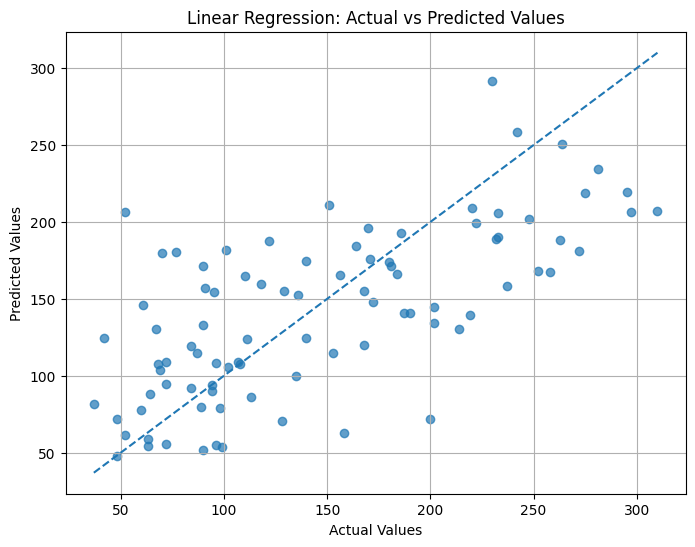

In [7]:
# Plot Actual vs Predicted values

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Actual vs Predicted Values")
plt.grid(True)

plt.show()

In [8]:
# Display final model performance

print("=" * 45)
print("LINEAR REGRESSION MODEL PERFORMANCE")
print("=" * 45)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")
print(f"R² (%) : {r2 * 100:.2f}%")

LINEAR REGRESSION MODEL PERFORMANCE
MAE  : 42.7941
MSE  : 2900.1936
RMSE : 53.8534
R²   : 0.4526
R² (%) : 45.26%


## Result and Conclusion

Linear Regression was successfully implemented on the Diabetes dataset to predict a continuous target variable.

The dataset was divided into training and testing sets, with 80% of the data used for training and 20% used for testing. A Linear Regression model was trained using the ten available input features.

The performance of the model was evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

The Actual vs Predicted plot shows the relationship between the actual target values and the values predicted by the Linear Regression model. Predictions closer to the diagonal reference line indicate better model performance.

The obtained evaluation metrics demonstrate that Linear Regression can effectively model the relationship between the input features and the continuous target variable.

Therefore, Linear Regression was successfully applied and evaluated, demonstrating its usefulness for solving supervised regression problems.